In [1]:
# 1. Clear out existing versions
!pip uninstall -y torch torchvision torchaudio

# 2. Install a version compatible with Python 3.12 + CUDA 11.8 (for P100)
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu118

# 3. Reinstall ultralytics
!pip install ultralytics

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.7/857.7 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 95.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 77.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 53.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 104.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6

In [2]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
DATASET_PATH = "/kaggle/input/datasets/sekhsujonhaque/cape-gooseberry-detection-dataset/final_dataset"
print(os.listdir(DATASET_PATH))

['valid', 'test', 'train']


In [4]:
for root, dirs, files in os.walk(DATASET_PATH):
    print(root)
    break

/kaggle/input/datasets/sekhsujonhaque/cape-gooseberry-detection-dataset/final_dataset


In [5]:
yaml_content = f"""
path: {DATASET_PATH}
train: train/images
val: valid/images
nc: 1
names: ['physalis']
"""
with open("data.yaml", "w") as f:
    f.write(yaml_content)
print("data.yaml created successfully")

data.yaml created successfully


In [6]:
model = YOLO('yolov8s.pt')

In [7]:
results = model.train(
    data = 'data.yaml', 
    epochs = 100, 
    imgsz = 768, 
    batch = 16, 
    patience = 20,    # <--- ADD THIS: Stops if no improvement for 20 epochs
    nbs = 64, 
    lr0 = 0.01, 
    lrf = 0.01, 
    dropout = 0.1, 
    name = 'fruit_detection_v2', 
    device = 0
)
metrics = model.val()
print("Model Training Done Sucessfully.")

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.4.0+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_detection_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20

In [8]:
import shutil
shutil.make_archive(
    '/kaggle/working/output_files',
    'zip',
    '/kaggle/working/runs'
)
print("ZIP created sucessfully")

ZIP created sucessfully


In [9]:
# Export the trained model to ONNX format for Render/CPU hosting
success = model.export(format='onnx', imgsz=768)
print("Model exported to ONNX successfully for deployment!")

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.4.0+cu118 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/detect/fruit_detection_v2/weights/best.pt' with input shape (1, 3, 768, 768) BCHW and output shape(s) (1, 5, 12096) (21.5 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 193ms
 Downloaded onnxruntime-gpu
Prepared 2 packages in 2.19s
Installed 2 packages in 15ms
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 2.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 19...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 4.8s, saved as '/kaggle/working/runs/det

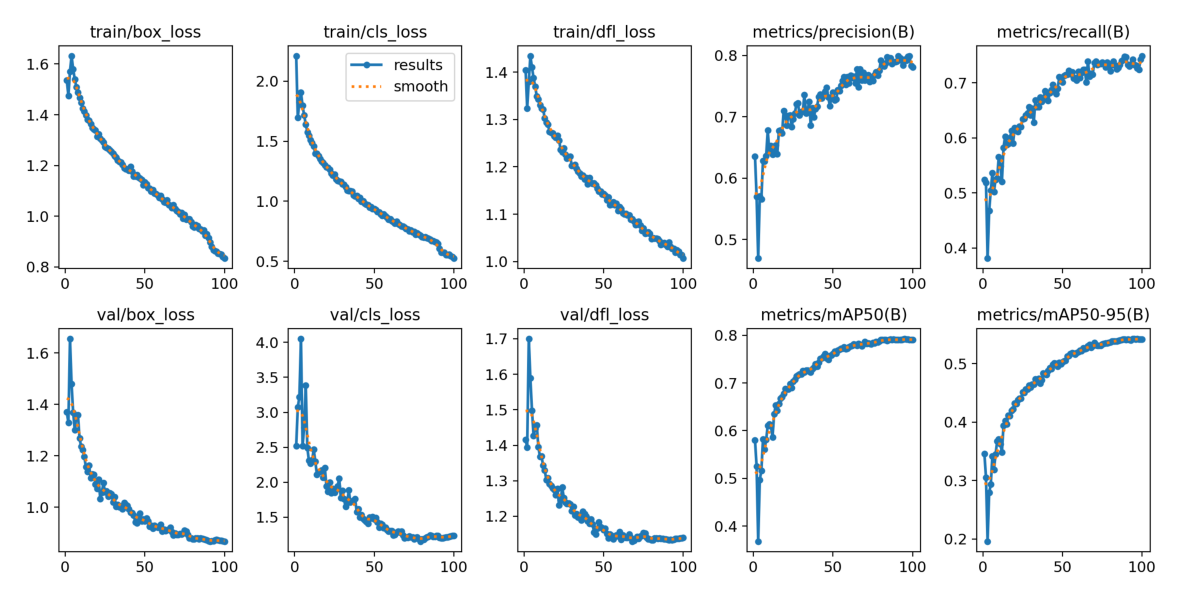

In [10]:
import matplotlib.pyplot as plt
import cv2

# Path to the results image generated by YOLO
results_path = '/kaggle/working/runs/detect/fruit_detection_v2/results.png'

if os.path.exists(results_path):
    img = cv2.imread(results_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()